In [120]:
from pathlib import Path
import os
import zipfile
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageOps

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    cohen_kappa_score,
    confusion_matrix,
    classification_report
)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

from tqdm.auto import tqdm

In [121]:
SEED = 42

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.backends.cudnn.benchmark = True

print("DEVICE:", DEVICE)

DEVICE: cuda


In [122]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [123]:
PROJECT_DIR = Path("/content/drive/MyDrive/Knee_OA_Project")
ZIP_PATH = PROJECT_DIR / "archive (10).zip"
DATA_DIR = Path("/content/kneeoa_data")

if not DATA_DIR.exists():
    print("Extracting dataset...")
    with zipfile.ZipFile(ZIP_PATH, "r") as zf:
        zf.extractall(DATA_DIR)
    print("Done.")
else:
    print("Dataset already extracted.")

EXPERIMENT_NAME = "resnet50_fullimg256_wce_v1"
RUN_DIR = PROJECT_DIR / "experiments" / EXPERIMENT_NAME
RUN_DIR.mkdir(parents=True, exist_ok=True)

CKPT_PATH = RUN_DIR / "best_model.pt"
HISTORY_PATH = RUN_DIR / "history.csv"
TEST_PREDS_PATH = RUN_DIR / "test_predictions.csv"
CM_PATH = RUN_DIR / "test_confusion_matrix.png"
SUMMARY_PATH = RUN_DIR / "summary.txt"

print("RUN_DIR:", RUN_DIR)

Dataset already extracted.
RUN_DIR: /content/drive/MyDrive/Knee_OA_Project/experiments/resnet50_fullimg256_wce_v1


In [124]:
CLASS_NAMES = ["0", "1", "2", "3", "4"]
LABEL_MAP = {c: int(c) for c in CLASS_NAMES}
SPLITS = ["train", "val", "test"]
VALID_EXTS = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"}

rows = []
for split in SPLITS:
    split_dir = DATA_DIR / split
    for cls in CLASS_NAMES:
        cls_dir = split_dir / cls
        for p in cls_dir.rglob("*"):
            if p.is_file() and p.suffix.lower() in VALID_EXTS:
                rows.append({
                    "path": str(p),
                    "label": LABEL_MAP[cls],
                    "split": split
                })

df = pd.DataFrame(rows)
print(df.groupby(["split", "label"]).size().unstack(fill_value=0))
print("Total:", len(df))
df.head()

label     0     1     2    3    4
split                            
test    639   296   447  223   51
train  2286  1046  1516  757  173
val     328   153   212  106   27
Total: 8260


,path,label,split
0,/content/kneeoa_data/train/0/9411555R.png,0,train
1,/content/kneeoa_data/train/0/9307109L.png,0,train
2,/content/kneeoa_data/train/0/9356765R.png,0,train
3,/content/kneeoa_data/train/0/9996345L.png,0,train
4,/content/kneeoa_data/train/0/9177091R.png,0,train


In [125]:
train_df = df[df["split"] == "train"].reset_index(drop=True)
val_df   = df[df["split"] == "val"].reset_index(drop=True)
test_df  = df[df["split"] == "test"].reset_index(drop=True)

print(len(train_df), len(val_df), len(test_df))

5778 826 1656


In [126]:
IMG_SIZE = 256
BATCH_SIZE = 32
NUM_WORKERS = 0

EPOCHS = 15
PATIENCE = 4

LR = 2e-4
WEIGHT_DECAY = 1e-4

print({
    "IMG_SIZE": IMG_SIZE,
    "BATCH_SIZE": BATCH_SIZE,
    "EPOCHS": EPOCHS,
    "PATIENCE": PATIENCE,
    "LR": LR,
    "WEIGHT_DECAY": WEIGHT_DECAY,
    "NUM_WORKERS": NUM_WORKERS
})

{'IMG_SIZE': 256, 'BATCH_SIZE': 32, 'EPOCHS': 15, 'PATIENCE': 4, 'LR': 0.0002, 'WEIGHT_DECAY': 0.0001, 'NUM_WORKERS': 0}


In [127]:
train_tfms = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(7),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

eval_tfms = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

In [128]:
class KneeOADataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["path"])
        img = ImageOps.exif_transpose(img)
        y = int(row["label"])

        if self.transform is not None:
            img = self.transform(img)

        return img, y, row["path"]

In [129]:
train_loader = DataLoader(
    KneeOADataset(train_df, train_tfms),
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    KneeOADataset(val_df, eval_tfms),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

test_loader = DataLoader(
    KneeOADataset(test_df, eval_tfms),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

xb, yb, pb = next(iter(train_loader))
print("Images:", xb.shape)
print("Labels:", yb.shape)
print("Example labels:", yb[:10].tolist())
print("Example path:", pb[0])

Images: torch.Size([32, 3, 256, 256])
Labels: torch.Size([32])
Example labels: [3, 1, 1, 0, 0, 2, 2, 3, 2, 2]
Example path: /content/kneeoa_data/train/3/9716984R.png


In [130]:
label_counts = train_df["label"].value_counts().sort_index()
counts = label_counts.values.astype(np.float32)

class_weights = 1.0 / counts
class_weights = class_weights / class_weights.sum() * len(class_weights)
class_weights = torch.tensor(class_weights, dtype=torch.float32, device=DEVICE)

print("Train label counts:\n", label_counts)
print("Class weights:", class_weights)

Train label counts:
 label
0    2286
1    1046
2    1516
3     757
4     173
Name: count, dtype: int64
Class weights: tensor([0.2389, 0.5222, 0.3603, 0.7215, 3.1571], device='cuda:0')


In [131]:
model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
model.fc = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(model.fc.in_features, 5)
)
model = model.to(DEVICE)

print("Model ready.")

Model ready.


In [132]:
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2
)

scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE.type == "cuda"))

In [133]:
def plus_minus_one_accuracy(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    return float(np.mean(np.abs(y_true - y_pred) <= 1))

def compute_metrics(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "qwk": cohen_kappa_score(y_true, y_pred, weights="quadratic"),
        "pm1_accuracy": plus_minus_one_accuracy(y_true, y_pred)
    }

In [134]:
def run_one_epoch(model, loader, optimizer=None):
    is_train = optimizer is not None
    model.train(is_train)

    losses = []
    y_true_all = []
    y_pred_all = []

    pbar = tqdm(loader, leave=False)

    for images, labels, _ in pbar:
        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        with torch.cuda.amp.autocast(enabled=(DEVICE.type == "cuda")):
            logits = model(images)
            loss = criterion(logits, labels)

        if is_train:
            optimizer.zero_grad(set_to_none=True)
            scaler.scale(loss).backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()

        preds = torch.argmax(logits, dim=1)

        losses.append(loss.item())
        y_true_all.extend(labels.detach().cpu().numpy().tolist())
        y_pred_all.extend(preds.detach().cpu().numpy().tolist())

        pbar.set_postfix(loss=f"{np.mean(losses):.4f}")

    metrics = compute_metrics(y_true_all, y_pred_all)
    metrics["loss"] = float(np.mean(losses))
    return metrics

In [135]:
history = []
best_f1 = -1.0
best_epoch = -1
patience_counter = 0

for epoch in range(1, EPOCHS + 1):
    print(f"\n===== Epoch {epoch}/{EPOCHS} =====")

    train_metrics = run_one_epoch(model, train_loader, optimizer=optimizer)
    val_metrics = run_one_epoch(model, val_loader, optimizer=None)

    scheduler.step(val_metrics["f1_macro"])

    row = {
        "epoch": epoch,
        **{f"train_{k}": v for k, v in train_metrics.items()},
        **{f"val_{k}": v for k, v in val_metrics.items()},
        "lr": float(optimizer.param_groups[0]["lr"])
    }
    history.append(row)

    print("Train:", train_metrics)
    print("Val  :", val_metrics)

    current_f1 = val_metrics["f1_macro"]

    if current_f1 > best_f1:
        best_f1 = current_f1
        best_epoch = epoch
        patience_counter = 0

        torch.save({
            "epoch": int(epoch),
            "model_state_dict": model.state_dict(),
            "val_metrics": {k: float(v) for k, v in val_metrics.items()},
            "config": {
                "IMG_SIZE": IMG_SIZE,
                "BATCH_SIZE": BATCH_SIZE,
                "LR": LR,
                "WEIGHT_DECAY": WEIGHT_DECAY
            }
        }, CKPT_PATH)

        print(f"Saved best checkpoint to: {CKPT_PATH}")
    else:
        patience_counter += 1
        print(f"No improvement. Patience: {patience_counter}/{PATIENCE}")

    pd.DataFrame(history).to_csv(HISTORY_PATH, index=False)

    if patience_counter >= PATIENCE:
        print("Early stopping triggered.")
        break

print(f"\nBest epoch: {best_epoch}")
print(f"Best val macro F1: {best_f1:.4f}")


===== Epoch 1/15 =====


  0%|          | 0/181 [00:00<?, ?it/s]

  0%|          | 0/26 [00:00<?, ?it/s]

Train: {'accuracy': 0.43094496365524404, 'precision_macro': 0.4141628307255532, 'recall_macro': 0.42277750260878816, 'f1_macro': 0.4166260489642054, 'balanced_accuracy': np.float64(0.42277750260878816), 'qwk': np.float64(0.49365346558853906), 'pm1_accuracy': 0.7940463828314296, 'loss': 1.2624369164856757}
Val  : {'accuracy': 0.5193704600484261, 'precision_macro': 0.511707044061583, 'recall_macro': 0.5368433347670509, 'f1_macro': 0.5140199090690332, 'balanced_accuracy': np.float64(0.5368433347670509), 'qwk': np.float64(0.6475524475524477), 'pm1_accuracy': 0.8401937046004843, 'loss': 1.1180320840615492}
Saved best checkpoint to: /content/drive/MyDrive/Knee_OA_Project/experiments/resnet50_fullimg256_wce_v1/best_model.pt

===== Epoch 2/15 =====


  0%|          | 0/181 [00:00<?, ?it/s]

...

  0%|          | 0/26 [00:00<?, ?it/s]

Train: {'accuracy': 0.7360678435444791, 'precision_macro': 0.7653811530147777, 'recall_macro': 0.7826690166505654, 'f1_macro': 0.771240979708268, 'balanced_accuracy': np.float64(0.7826690166505654), 'qwk': np.float64(0.8655967372680438), 'pm1_accuracy': 0.9640013845621322, 'loss': 0.5299307586244457}
Val  : {'accuracy': 0.5980629539951574, 'precision_macro': 0.6688772431648886, 'recall_macro': 0.6742905854881709, 'f1_macro': 0.6536773087627203, 'balanced_accuracy': np.float64(0.6742905854881709), 'qwk': np.float64(0.7893383062182496), 'pm1_accuracy': 0.9552058111380145, 'loss': 0.9583348987194208}
No improvement. Patience: 3/4

===== Epoch 11/15 =====


  0%|          | 0/181 [00:00<?, ?it/s]

  0%|          | 0/26 [00:00<?, ?it/s]

Train: {'accuracy': 0.7954309449636553, 'precision_macro': 0.8277775795105949, 'recall_macro': 0.8381293851927838, 'f1_macro': 0.8301838198516205, 'balanced_accuracy': np.float64(0.8381293851927838), 'qwk': np.float64(0.8978602174627541), 'pm1_accuracy': 0.9747317410868813, 'loss': 0.4118707371021503}
Val  : {'accuracy': 0.6610169491525424, 'precision_macro': 0.6557782038652477, 'recall_macro': 0.6851269842702127, 'f1_macro': 0.6687001206376239, 'balanced_accuracy': np.float64(0.6851269842702127), 'qwk': np.float64(0.8072746691983623), 'pm1_accuracy': 0.9358353510895884, 'loss': 0.8982557683036878}
No improvement. Patience: 4/4
Early stopping triggered.

Best epoch: 7
Best val macro F1: 0.6765


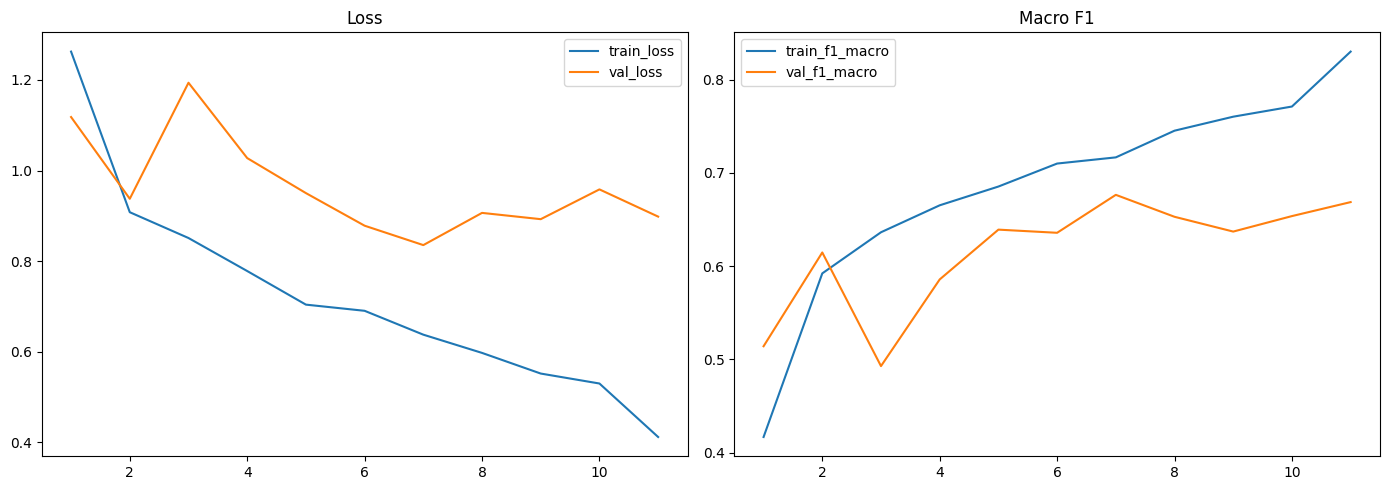

In [136]:
hist_df = pd.DataFrame(history)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(hist_df["epoch"], hist_df["train_loss"], label="train_loss")
axes[0].plot(hist_df["epoch"], hist_df["val_loss"], label="val_loss")
axes[0].set_title("Loss")
axes[0].legend()

axes[1].plot(hist_df["epoch"], hist_df["train_f1_macro"], label="train_f1_macro")
axes[1].plot(hist_df["epoch"], hist_df["val_f1_macro"], label="val_f1_macro")
axes[1].set_title("Macro F1")
axes[1].legend()

plt.tight_layout()
plt.show()

In [137]:
ckpt = torch.load(CKPT_PATH, map_location=DEVICE, weights_only=False)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()

print("Loaded best checkpoint from epoch:", ckpt["epoch"])
print("Best val metrics:", ckpt["val_metrics"])

Loaded best checkpoint from epoch: 7
Best val metrics: {'accuracy': 0.6452784503631961, 'precision_macro': 0.6798423480878576, 'recall_macro': 0.6867793939685606, 'f1_macro': 0.6764819201427607, 'balanced_accuracy': 0.6867793939685606, 'qwk': 0.8077842476248851, 'pm1_accuracy': 0.9455205811138014, 'loss': 0.8353994121918311}


In [138]:
@torch.no_grad()
def predict_loader(model, loader):
    model.eval()

    y_true_all = []
    y_pred_all = []
    all_paths = []

    for images, labels, paths in tqdm(loader):
        images = images.to(DEVICE, non_blocking=True)

        with torch.cuda.amp.autocast(enabled=(DEVICE.type == "cuda")):
            logits = model(images)

        preds = torch.argmax(logits, dim=1)

        y_true_all.extend(labels.numpy().tolist())
        y_pred_all.extend(preds.cpu().numpy().tolist())
        all_paths.extend(paths)

    return y_true_all, y_pred_all, all_paths

In [139]:
val_true, val_pred, _ = predict_loader(model, val_loader)
val_metrics = compute_metrics(val_true, val_pred)

print("Validation metrics:")
for k, v in val_metrics.items():
    print(f"{k}: {v:.4f}")

  0%|          | 0/26 [00:00<?, ?it/s]

Validation metrics:
accuracy: 0.6453
precision_macro: 0.6798
recall_macro: 0.6868
f1_macro: 0.6765
balanced_accuracy: 0.6868
qwk: 0.8078
pm1_accuracy: 0.9455


In [141]:
test_true, test_pred, test_paths = predict_loader(model, test_loader)
test_metrics = compute_metrics(test_true, test_pred)

print("Test metrics:")
for k, v in test_metrics.items():
    print(f"{k}: {v:.4f}")

  0%|          | 0/52 [00:00<?, ?it/s]

Test metrics:
accuracy: 0.6661
precision_macro: 0.6978
recall_macro: 0.6907
f1_macro: 0.6843
balanced_accuracy: 0.6907
qwk: 0.8432
pm1_accuracy: 0.9656


In [142]:
test_true, test_pred, test_paths = predict_loader(model, test_loader)
test_metrics = compute_metrics(test_true, test_pred)

print(test_metrics)
print(classification_report(test_true, test_pred, digits=4))

  0%|          | 0/52 [00:00<?, ?it/s]

{'accuracy': 0.6660628019323671, 'precision_macro': 0.6978205822174598, 'recall_macro': 0.690726688475549, 'f1_macro': 0.6842941955489806, 'balanced_accuracy': np.float64(0.690726688475549), 'qwk': np.float64(0.8432218266486676), 'pm1_accuracy': 0.9655797101449275}
              precision    recall  f1-score   support

           0     0.7783    0.7966    0.7873       639
           1     0.3489    0.5034    0.4122       296
           2     0.7849    0.4899    0.6033       447
           3     0.7500    0.8206    0.7837       223
           4     0.8269    0.8431    0.8350        51

    accuracy                         0.6661      1656
   macro avg     0.6978    0.6907    0.6843      1656
weighted avg     0.7010    0.6661    0.6716      1656



In [143]:
test_true, test_pred, test_paths = predict_loader(model, test_loader)
test_metrics = compute_metrics(test_true, test_pred)

print("Test metrics:")
for k, v in test_metrics.items():
    print(f"{k}: {v:.4f}")

  0%|          | 0/52 [00:00<?, ?it/s]

Test metrics:
accuracy: 0.6661
precision_macro: 0.6978
recall_macro: 0.6907
f1_macro: 0.6843
balanced_accuracy: 0.6907
qwk: 0.8432
pm1_accuracy: 0.9656


In [144]:
print(classification_report(test_true, test_pred, digits=4))

              precision    recall  f1-score   support

           0     0.7783    0.7966    0.7873       639
           1     0.3489    0.5034    0.4122       296
           2     0.7849    0.4899    0.6033       447
           3     0.7500    0.8206    0.7837       223
           4     0.8269    0.8431    0.8350        51

    accuracy                         0.6661      1656
   macro avg     0.6978    0.6907    0.6843      1656
weighted avg     0.7010    0.6661    0.6716      1656



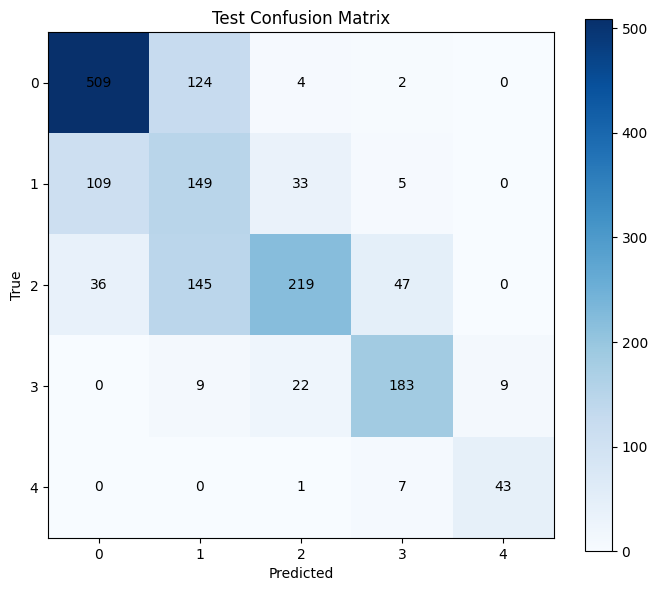

Saved confusion matrix to: /content/drive/MyDrive/Knee_OA_Project/experiments/resnet50_fullimg256_wce_v1/test_confusion_matrix.png


In [145]:
cm = confusion_matrix(test_true, test_pred)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm, cmap="Blues")

ax.set_xticks(range(5))
ax.set_yticks(range(5))
ax.set_xticklabels(CLASS_NAMES)
ax.set_yticklabels(CLASS_NAMES)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Test Confusion Matrix")

for i in range(5):
    for j in range(5):
        ax.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar(im)
plt.tight_layout()
plt.savefig(CM_PATH, dpi=200, bbox_inches="tight")
plt.show()

print("Saved confusion matrix to:", CM_PATH)

In [146]:
pred_df = pd.DataFrame({
    "path": test_paths,
    "y_true": test_true,
    "y_pred": test_pred
})
pred_df["abs_error"] = (pred_df["y_true"] - pred_df["y_pred"]).abs()

pred_df.to_csv(TEST_PREDS_PATH, index=False)
print("Saved:", TEST_PREDS_PATH)
pred_df.head()

Saved: /content/drive/MyDrive/Knee_OA_Project/experiments/resnet50_fullimg256_wce_v1/test_predictions.csv


,path,y_true,y_pred,abs_error
0,/content/kneeoa_data/test/0/9827858L.png,0,0,0
1,/content/kneeoa_data/test/0/9030418R.png,0,0,0
2,/content/kneeoa_data/test/0/9594682R.png,0,0,0
3,/content/kneeoa_data/test/0/9733523L.png,0,1,1
4,/content/kneeoa_data/test/0/9789177L.png,0,0,0


In [147]:
summary_lines = []
summary_lines.append(f"Experiment: {EXPERIMENT_NAME}")
summary_lines.append(f"Best epoch: {ckpt['epoch']}")
summary_lines.append("")

summary_lines.append("Validation metrics:")
for k, v in val_metrics.items():
    summary_lines.append(f"{k}: {v:.4f}")

summary_lines.append("")
summary_lines.append("Test metrics:")
for k, v in test_metrics.items():
    summary_lines.append(f"{k}: {v:.4f}")

summary_text = "\n".join(summary_lines)

with open(SUMMARY_PATH, "w") as f:
    f.write(summary_text)

print(summary_text)
print("\nSaved summary to:", SUMMARY_PATH)

Experiment: resnet50_fullimg256_wce_v1
Best epoch: 7

Validation metrics:
accuracy: 0.6453
precision_macro: 0.6798
recall_macro: 0.6868
f1_macro: 0.6765
balanced_accuracy: 0.6868
qwk: 0.8078
pm1_accuracy: 0.9455

Test metrics:
accuracy: 0.6661
precision_macro: 0.6978
recall_macro: 0.6907
f1_macro: 0.6843
balanced_accuracy: 0.6907
qwk: 0.8432
pm1_accuracy: 0.9656

Saved summary to: /content/drive/MyDrive/Knee_OA_Project/experiments/resnet50_fullimg256_wce_v1/summary.txt
